Analysis of Brooklyn Schools- Day 2
Anny H.LLosa

In [ ]:
# Basic library imports

import pandas as pd
import numpy as np

print("Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully
Pandas version: 2.3.3


In [9]:
# Load CSV file
try:
    df = pd.read_csv('high-school-directory.csv')
    print(df.head())
    
except FileNotFoundError:
    print("ERROR: 'high-school-directory.csv' not found")
    import glob
    for f in glob.glob("*.csv"):
        print(f"  - {f}")
except Exception as e:
    print(f"An error occurred: {e}")

      dbn                                        school_name    borough  \
0  27Q260          Frederick Douglass Academy VI High School     Queens   
1  21K559        Life Academy High School for Film and Music   Brooklyn   
2  16K393     Frederick Douglass Academy IV Secondary School   Brooklyn   
3  08X305                               Pablo Neruda Academy      Bronx   
4  03M485  Fiorello H. LaGuardia High School of Music & A...  Manhattan   

  building_code  phone_number    fax_number  grade_span_min  grade_span_max  \
0          Q465  718-471-2154  718-471-2890             9.0              12   
1          K400  718-333-7750  718-333-7775             9.0              12   
2          K026  718-574-2820  718-574-2821             9.0              12   
3          X450  718-824-1682  718-824-1663             9.0              12   
4          M485  212-496-0700  212-724-5748             9.0              12   

   expgrade_span_min  expgrade_span_max  ... Council District Census Tract

In [10]:
# Clean column names: lowercase letters and underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Column names cleaned")

Column names cleaned


In [30]:
# Filter for Brooklyn schools
brooklyn_df = df[df["borough"].str.lower() == "brooklyn"].copy()
print(f"Schools in Brooklyn: {len(brooklyn_df)}")

Schools in Brooklyn: 121


In [29]:
# Assuming 'dbn' is the unique identifier
unique_schools = brooklyn_df["dbn"].nunique()
print(f"Unique schools in Brooklyn: {unique_schools}")

Unique schools in Brooklyn: 121


In [31]:
# Find grade columns
col_grade = [col for col in brooklyn_df.columns if "grade" in col.lower()]
print(f"Grade-related columns: {col_grade}")

# Assuming we have grade_span_max column
col_analysis = "grade_span_max"
if "grade_span_max" in brooklyn_df.columns:
    brooklyn_df[col_analysis] = pd.to_numeric(brooklyn_df[col_analysis], errors='coerce')

    schools_with_9th = brooklyn_df[brooklyn_df["grade_span_max"] >= 9]
    print(f"Answers with analysis of Brooklyn:")
    print(f"Schools offering 9th grade in Brooklyn: {len(schools_with_9th)}")
    
else:
    print(f"Not finding column '{col_analysis}' in dataset")
    print("Grade span column not found")

Grade-related columns: ['grade_span_min', 'grade_span_max', 'expgrade_span_min', 'expgrade_span_max']
Answers with analysis of Brooklyn:
Schools offering 9th grade in Brooklyn: 121


In [14]:
# Count schools by council district
col_district = "council_district"
if "council_district" in brooklyn_df.columns:
    brooklyn_df[col_district] = brooklyn_df[col_district].astype(str).str.strip().str.upper()
    district_counts = brooklyn_df[col_district].value_counts().sort_index()
    print("Schools by district:")
    print(f"Counts of schools in each council district in Brooklyn {col_district}:")
    print(district_counts)
else:
    print(f"Note: Column '{col_district}' not found in dataset")

Schools by district:
Counts of schools in each council district in Brooklyn council_district:
council_district
33.0    21
34.0     9
35.0    10
36.0     8
37.0    12
38.0     1
39.0     6
40.0     9
41.0     7
42.0     8
43.0     3
44.0     3
45.0     4
46.0     7
47.0     9
48.0     4
Name: count, dtype: int64


In [ ]:
# Average students per district
col_students = "total_students"
col_district = "council_district"
if col_students in brooklyn_df.columns and col_district in brooklyn_df.columns:
    avg_students= brooklyn_df.groupby(col_district)[col_students].mean().round(0).astype(int)
    print("School density summary:")
    print(f"Average number of students by council district in Brooklyn ({col_district}):")
    print(avg_students)
else:
    print("Not valid to compute averages")
    print(f"Verify if Columns '{col_students}' and '{col_district}' exist in the dataset")

School density summary:
Average number of students by council district in Brooklyn (council_district):
council_district
33.0     453
34.0     604
35.0    1182
36.0     337
37.0     431
38.0    1309
39.0     452
40.0     389
41.0     392
42.0     354
43.0    2997
44.0    2545
45.0    1247
46.0     339
47.0     825
48.0    1206
Name: total_students, dtype: int64


In [ ]:
# Summary of grade_span_max by borough
col_grade = "grade_span_max"
col_borough = "borough"
if col_grade in df.columns and col_borough in df.columns:
    df[col_grade] = pd.to_numeric(df[col_grade], errors='coerce')
    grade_summary = df.groupby(col_borough)[col_grade].describe()
    print("Summary of maximum grades by district:")
    print(f"Descriptive statistics of '{col_grade}' grouped by '{col_borough}':")
    print(grade_summary)
else:
    print("Cannot compute grade summary")
    print(f"Verify if Columns '{col_grade}' and '{col_borough}' not found in the dataset")

Summary of maximum grades by district:
Descriptive statistics of 'grade_span_max' grouped by 'borough':
               count       mean       std   min   25%   50%   75%   max
borough                                                                
Bronx          118.0  11.906780  0.369506   9.0  12.0  12.0  12.0  12.0
Brooklyn       121.0  11.933884  0.381566   9.0  12.0  12.0  12.0  12.0
Manhattan      106.0  11.877358  0.472135   9.0  12.0  12.0  12.0  12.0
Queens          80.0  11.825000  0.497462  10.0  12.0  12.0  12.0  12.0
Staten Island   10.0  12.000000  0.000000  12.0  12.0  12.0  12.0  12.0


1.Bar Chart: Number of Schools by Council District “Brooklyn“

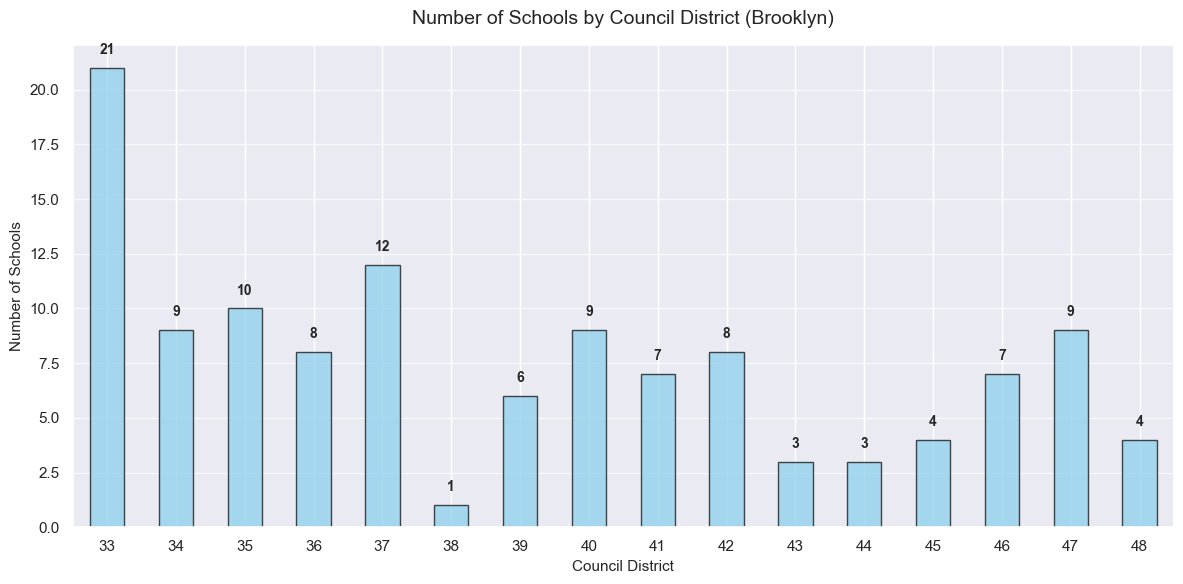

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

col_district = "council_district"

if col_district in brooklyn_df.columns:
    counts = brooklyn_df[col_district].dropna().astype(int).value_counts().sort_index()
    plt.figure(figsize=(12, 6))
    counts.plot(kind="bar", color="skyblue", edgecolor="black", alpha=0.7)
    plt.title("Number of Schools by Council District Brooklyn", fontsize=14, pad=15)
    plt.xlabel("Council District", fontsize=11)
    plt.ylabel("Number of Schools", fontsize=11)
    plt.xticks(rotation=0)
    plt.grid(axis="y", linestyle="-", alpha=0.7)

    for i, v in enumerate(counts):
        plt.text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot create visualization: Column '{col_district}' not found in dataset")

2.Pie Chart and Count Bar Chart: Brooklyn Educational Offer Summary


Educational Level Analysis in Brooklyn Schools


/var/folders/8h/_1bz0szd6718m8lc4l3bpt200000gn/T/ipykernel_56019/216999609.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=level_counts.index, y=level_counts.values, ax=ax2, palette="viridis")


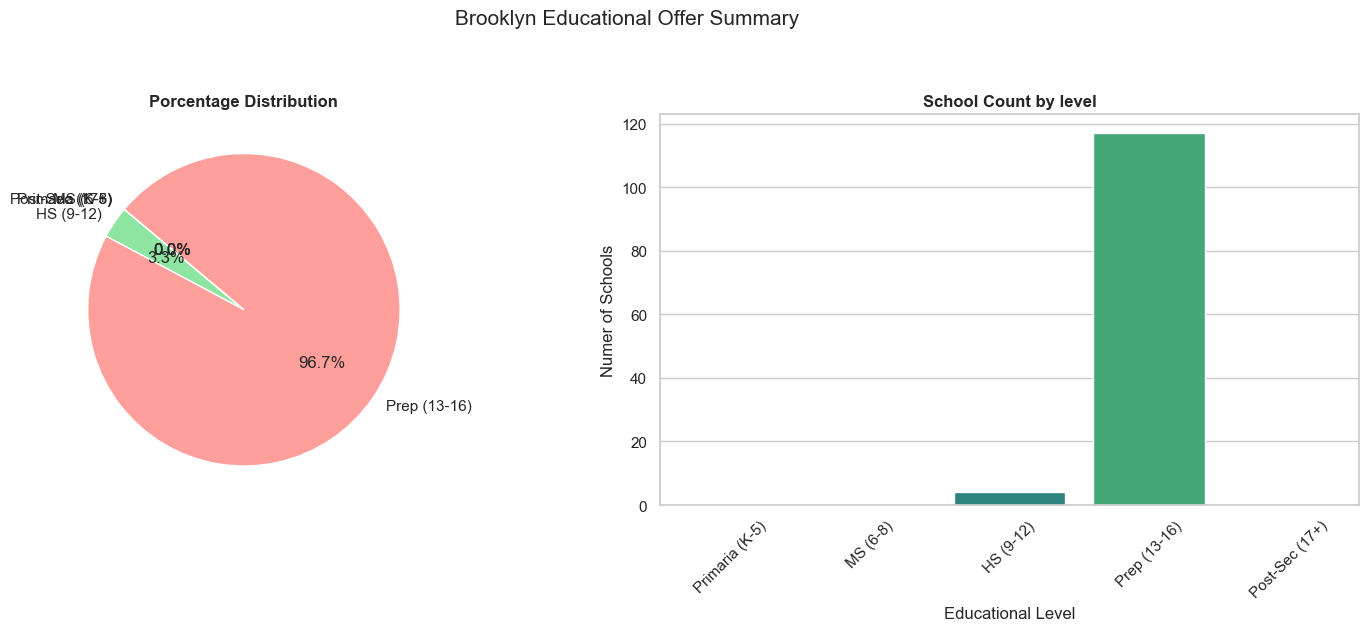

Analysis complete. Total schools analyzed: 121


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("\n" + "="*60)
print("Educational Level Analysis in Brooklyn Schools")
print("="*60)

if "grade_span_max" in brooklyn_df.columns:
    brooklyn_df["grade_span_max"] = pd.to_numeric(brooklyn_df["grade_span_max"], errors='coerce')
    bins = [0, 5, 8, 12, 16, 25]
    labels = ['Primaria (K-5)', 'MS (6-8)', 'HS (9-12)', 'Prep (13-16)', 'Post-Sec (17+)']
    brooklyn_df["education_level"] = pd.cut(
        brooklyn_df["grade_span_max"],
        bins=bins,
        labels=labels,
        right=False
)

    level_counts = brooklyn_df["education_level"].value_counts().sort_index()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    #Chart 1 Porcentage Pie Chart
    modern_colors = sns.color_palette("pastel")
    ax1.pie(
        level_counts,
        labels=level_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=modern_colors
)
    ax1.set_title('Porcentage Distribution', fontsize=12, fontweight='bold')
    #Chart 2 Count Bar Chart
    sns.barplot(x=level_counts.index, y=level_counts.values, ax=ax2, palette="viridis")
    ax2.set_title('School Count by level', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Numer of Schools')
    ax2.set_xlabel('Educational Level')
    plt.xticks(rotation=45)

    plt.suptitle('Brooklyn Educational Offer Summary', fontsize=15, y=1.05)
    plt.tight_layout()
    plt.show()

    # Mensaje de confirmación para el reporte
    print(f"Analysis complete. Total schools analyzed: {level_counts.sum()}")
else:
    print("Cannot create visualization: Column 'grade_span_max' not found in the dataset")

3.Bar Chart: Educational Capacity Analysis by District Brooklyn


Visualization: District Comparative Dashboard


/var/folders/8h/_1bz0szd6718m8lc4l3bpt200000gn/T/ipykernel_56019/5723060.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_data, x="council_district", y="school_count", ax=ax1, palette="Blues_d")
/var/folders/8h/_1bz0szd6718m8lc4l3bpt200000gn/T/ipykernel_56019/5723060.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_data, x="council_district", y="total_students", ax=ax2, palette="Reds_d")
/var/folders/8h/_1bz0szd6718m8lc4l3bpt200000gn/T/ipykernel_56019/5723060.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.ba

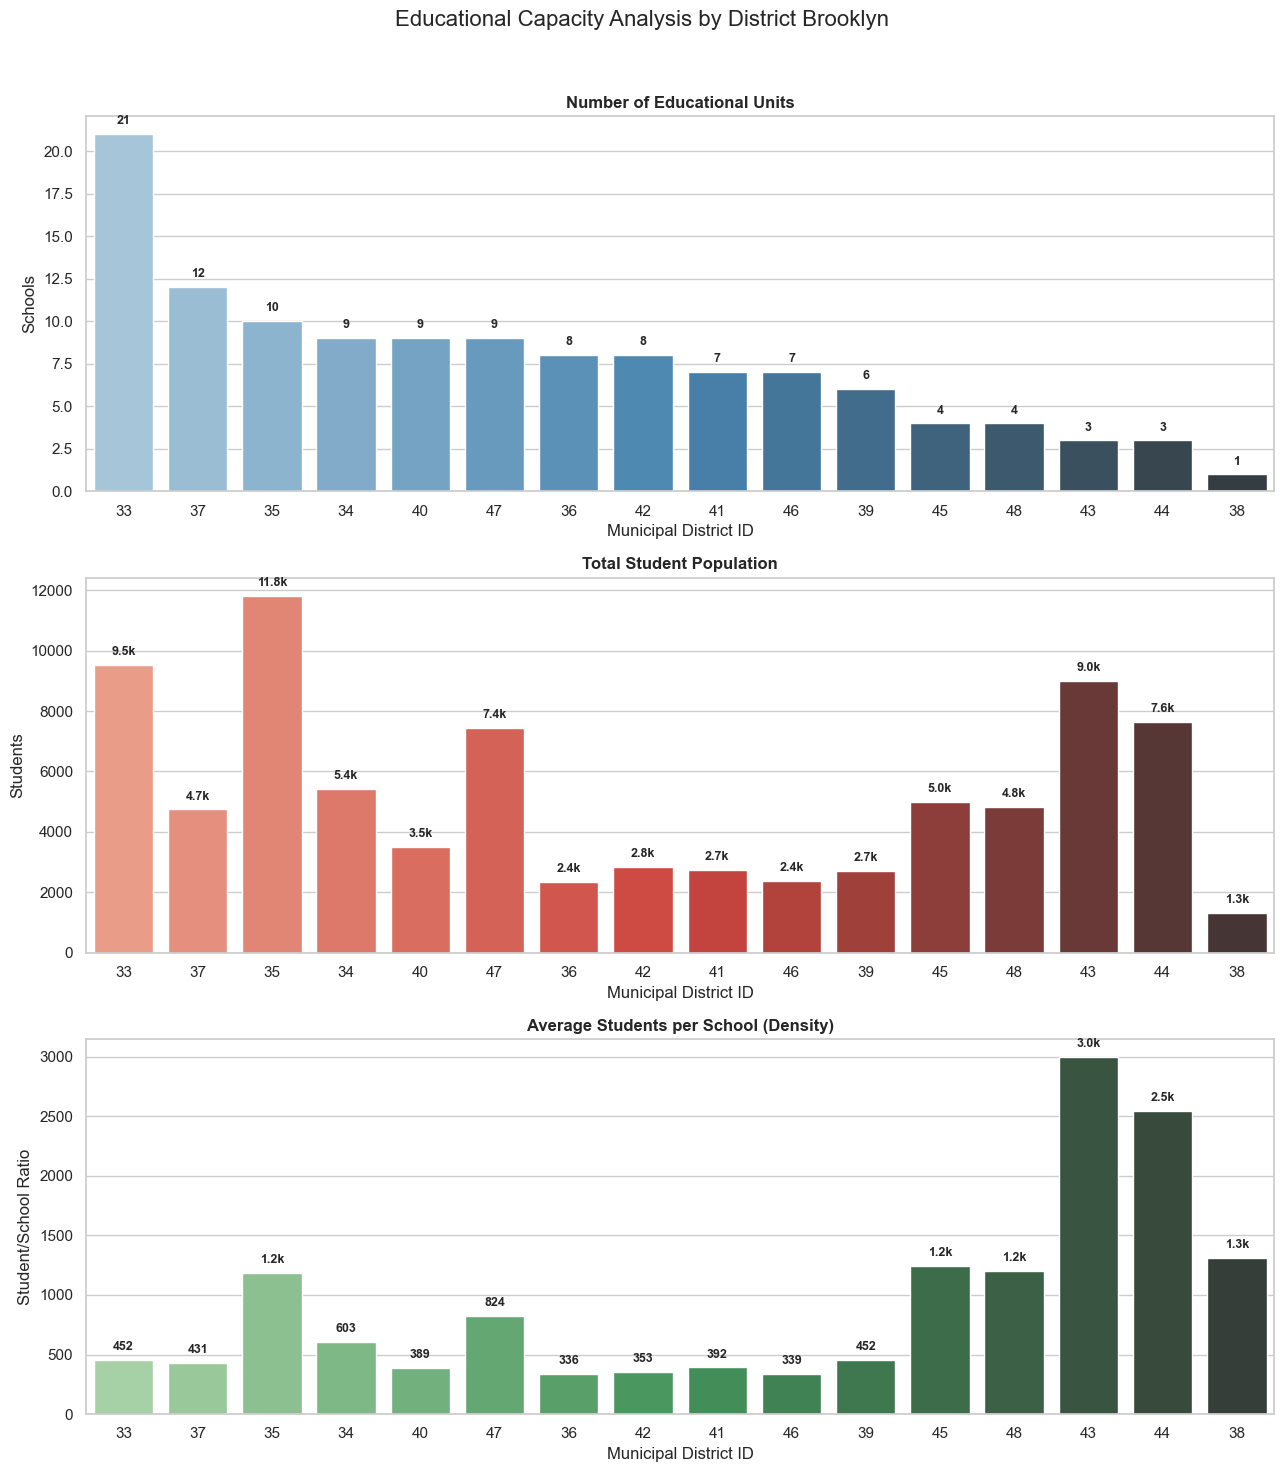

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("\n" + "="*60)
print("Visualization: District Comparative Dashboard")
print("="*60)

required = ["council_district", "total_students", "dbn"]
if all(col in brooklyn_df.columns for col in required):
    
    district_data = brooklyn_df.groupby("council_district").agg({
        "dbn": "count",
        "total_students": ["sum", "mean"]
    })
    
    district_data.columns = ["school_count", "total_students", "avg_students"]
    district_data = district_data.reset_index()
    
    district_data["council_district"] = district_data["council_district"].astype(int).astype(str)
    district_data = district_data.sort_values("school_count", ascending=False)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 15))
    
    # Chart 1: Number of Schools
    sns.barplot(data=district_data, x="council_district", y="school_count", ax=ax1, palette="Blues_d")
    ax1.set_title('Number of Educational Units', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Schools')

    # Chart 2: Student Population
    sns.barplot(data=district_data, x="council_district", y="total_students", ax=ax2, palette="Reds_d")
    ax2.set_title('Total Student Population', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Students')

    # Chart 3: Density (Students per School)
    sns.barplot(data=district_data, x="council_district", y="avg_students", ax=ax3, palette="Greens_d")
    ax3.set_title('Average Students per School (Density)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Student/School Ratio')

    for ax in [ax1, ax2, ax3]:
        ax.set_xlabel("Municipal District ID")
        for p in ax.patches:
            val = p.get_height()
            label = f'{val/1000:.1f}k' if val > 1000 else f'{int(val)}'
            ax.annotate(label, 
                        (p.get_x() + p.get_width() / 2., val), 
                        ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 5),
                        textcoords='offset points')

    plt.suptitle('Educational Capacity Analysis by District Brooklyn', fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

else:
    missing = [c for c in required if c not in brooklyn_df.columns]
    print(f"Could not generate dashboard. Missing columns: {missing}")

FINAL CONCLUSIONS AND STRATEGIC OBSERVATIONS

KEY INSIGTHS BASED ON BROOKLYN DATA ANALYSIS (n=121 schools)

1. CRITICAL GEOGRAPHICAL DISPARITY** The distribution of high schools across Brooklyn is significantly uneven. 
   Council District 33 serves as the primary educational hub with 21 schools, whereas Districts 43 and 44 show the lowest infrastructure availability with only 3 schools each. 
   This 7-to-1 ratio suggests a high concentration of services in specific corridors, leaving other areas with fewer local options.

2. EXTREME STUDENT DENSITY AND OVERCROWDING** The most striking finding is the variation in student density. 
   District 43 handles a massive average of 2,997 students per school**, nearly 9 times higher than District 36 (337 students/school). 
   This indicates that while some districts have fewer buildings, the load per building is extremely high, suggesting a critical need for infrastructure expansion or increased staffing in southern Brooklyn.

3. UNIFORM EDUCATIONAL PATHWAY** Statistical analysis confirms that the educational system is highly standardized. 
   The average maximum grade across all boroughs is 11.9, with a median of 12. 
   In Brooklyn, the standard deviation is low (0.38), confirming that almost all institutions are strictly focused on completing the traditional High School cycle (Grade 12), with no current expansion into post-secondary or transition grades (13+) within this dataset.



EXECUTIVE SUMMARY

1. Access Equity: There is a significant gap in school counts between northern and southern districts. Geographic location is a determining factor in 
   school choice availability.

2. Infrastructure Pressure: Districts 43 and 48 are operating at high density levels. Policy efforts should prioritize these areas to prevent overcrowding
   and maintain educational quality.

3. System Stability: The 9-12 grade span is the universal standard in NYC, providing a predictable pathway for students but showing little variation for 
   alternative vocational or extended secondary programs.


STRATEGIC RECOMMENDATIONS 

- Infrastructure Investment: Prioritize the construction or expansion of facilities in Districts 43, 44, and 45 to balance the student-to-school ratio.

- Resource Allocation: Distribute budget and personnel based on student density (Average Enrollment) rather than just the number of school buildings.

- Further Research: Conduct a follow-up analysis correlating these density figures with graduation rates to see if overcrowding in District 43 is 
  impacting academic performance.